Phase no 1: Data Understanding

- Importing libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score , classification_report
import tensorflow as tf
from tensorflow.keras import Sequential , layers
from tensorflow.keras.layers import Dense , Flatten


- Loading Dataset

In [2]:
dataset = pd.read_csv('customer_dataset.csv')

- checking top 2 rows of dataset

In [3]:
dataset.head(2)

,Customer ID,Age,Gender,City,Subscription Type,Monthly Spending,Tenure,Number of Purchases,Customer Support Requests,Login Frequency,Last Activity Date,Satisfaction Score,Churn Status
0,CUST-1001,58,Male,New York,Premium,92.00,15,2,3,Daily,2026-03-26,1,1
1,CUST-1002,20,Male,Los Angeles,Basic,14.65,39,1,0,Weekly,2026-03-29,5,1


- checking bottom 2 rows of dataset

In [4]:
dataset.tail(2)

,Customer ID,Age,Gender,City,Subscription Type,Monthly Spending,Tenure,Number of Purchases,Customer Support Requests,Login Frequency,Last Activity Date,Satisfaction Score,Churn Status
1498,CUST-2499,43,Male,Philadelphia,Premium,136.89,3,2,0,Bi-weekly,2026-04-09,2,0
1499,CUST-2500,21,Other,Chicago,Standard,32.56,5,1,2,Weekly,2026-06-07,3,0


- Checking null values in dataset if any

In [5]:
dataset.isnull().sum()

Customer ID                  0
Age                          0
Gender                       0
City                         0
Subscription Type            0
Monthly Spending             0
Tenure                       0
Number of Purchases          0
Customer Support Requests    0
Login Frequency              0
Last Activity Date           0
Satisfaction Score           0
Churn Status                 0
dtype: int64

- Checking duplicates in dataset and removing if any

In [6]:
print(f"The duplicates in the dataset is: {dataset.duplicated().sum()}")

The duplicates in the dataset is: 0


- Checking outliers in dataset

In [7]:
target_column = 'Churn Status'

q1 = dataset['Churn Status'].quantile(0.25)
q3 = dataset['Churn Status'].quantile(0.75)

iqr = q3-q1

lower_limit = q1 - (1.5 *iqr)
higher_limit = q3 + (1.5 *iqr)

outliers = dataset[(dataset[target_column]<lower_limit)| (dataset[target_column]>higher_limit)]
print(f'Total outlier in the {target_column} is: {len(outliers)}')

Total outlier in the Churn Status is: 338


- Encode categorical variables

In [8]:
dataset = dataset.drop(columns=['Customer ID'])

dataset['Last Activity Date'] = pd.to_datetime(dataset['Last Activity Date'])

categorical_cols = dataset.select_dtypes(include=['object']).columns.tolist()

dataset = pd.get_dummies(dataset, columns=categorical_cols, drop_first=True)
dataset.head(4)

,Age,Monthly Spending,Tenure,Number of Purchases,Customer Support Requests,Last Activity Date,Satisfaction Score,Churn Status,Gender_Male,Gender_Other,...,City_Philadelphia,City_Phoenix,City_San Antonio,City_San Diego,City_San Jose,Subscription Type_Premium,Subscription Type_Standard,Login Frequency_Daily,Login Frequency_Monthly,Login Frequency_Weekly
0,58,92.00,15,2,3,2026-03-26,1,1,True,False,...,False,False,False,False,False,True,False,True,False,False
1,20,14.65,39,1,0,2026-03-29,5,1,True,False,...,False,False,False,False,False,False,False,False,False,True
2,55,23.96,22,5,0,2026-05-24,4,0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,42,54.15,52,2,0,2026-04-13,2,0,True,False,...,True,False,False,False,False,False,True,False,True,False


- Distributing dataset into Train and testing data

In [9]:
X = dataset.drop(columns=['Churn Status','Last Activity Date'])  
Y = dataset['Churn Status']   

X_train_clean = X.select_dtypes(include = ['number','float'])
 

X_train, X_test, y_train, y_test = train_test_split(
    X_train_clean, Y, test_size=0.2, random_state=42
)

In [10]:
scaler = StandardScaler()

numerical_cols = ['Monthly Spending']

dataset[numerical_cols] = scaler.fit_transform(dataset[numerical_cols])
dataset[numerical_cols]

,Monthly Spending
0,0.790934
1,-1.159231
2,-0.924505
3,-0.163348
4,0.064318
...,...
1495,1.006751
1496,1.459563
1497,-0.400343
1498,1.922711


In [11]:
X_train.columns.tolist()

['Age',
 'Monthly Spending',
 'Tenure',
 'Number of Purchases',
 'Customer Support Requests',
 'Satisfaction Score']

- Phase (2) : Exploratory Data Analysis

- Analyze Age Distribution column

In [12]:
display(dataset['Age'].describe())

count    1500.000000
mean       46.767333
std        16.657156
min        18.000000
25%        32.000000
50%        47.000000
75%        61.000000
max        75.000000
Name: Age, dtype: float64

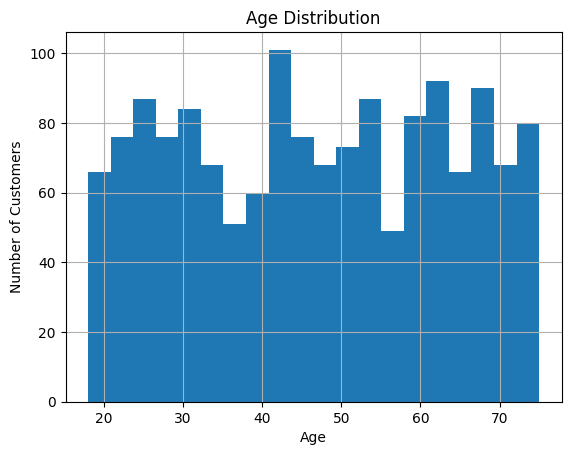

In [13]:
dataset['Age'].hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

- Analyze Gender Distribution

In [14]:
gender_counts = pd.Series({
    'Female': len(dataset) - dataset['Gender_Male'].sum() - dataset['Gender_Other'].sum(),
    'Male': dataset['Gender_Male'].sum(),
    'Other': dataset['Gender_Other'].sum()
})
display(gender_counts)

Female    515
Male      492
Other     493
dtype: int64

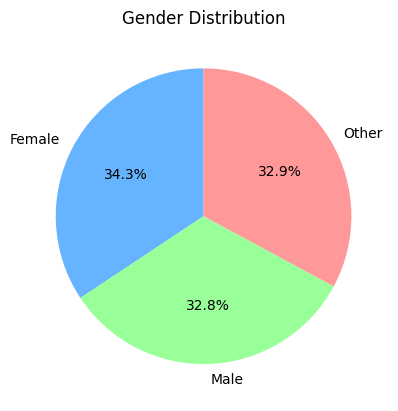

In [15]:
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,          
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff', '#99ff99', '#ff9999']  )
plt.title("Gender Distribution")
plt.show()



- Analyze Income Distribution

In [16]:
login_counts = dataset[['Login Frequency_Daily', 'Login Frequency_Weekly', 'Login Frequency_Monthly']].sum()
login_counts.index = ['Daily', 'Weekly', 'Monthly']
display(login_counts)


Daily      397
Weekly     364
Monthly    382
dtype: int64

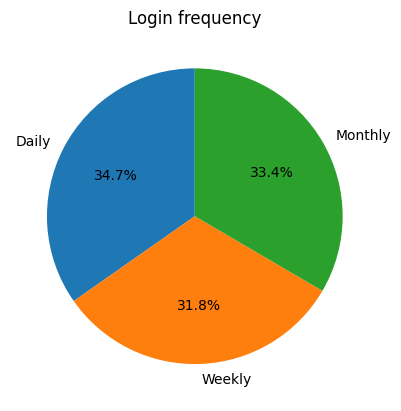

In [17]:
plt.pie(login_counts.values,
        labels = login_counts.index,
        autopct='%1.1f%%',
        startangle=90,
)
plt.title("Login frequency")
plt.show()

- Churn Distribution

In [18]:
churn_counts = dataset['Churn Status'].value_counts()
display(churn_counts)

Churn Status
0    1162
1     338
Name: count, dtype: int64

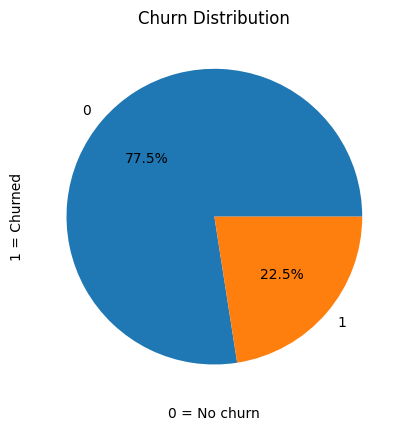

In [19]:
plt.pie(churn_counts.values,
        labels = churn_counts.index,
        autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.xlabel('0 = No churn')
plt.ylabel('1 = Churned')
plt.show()


- Correlational Matrix

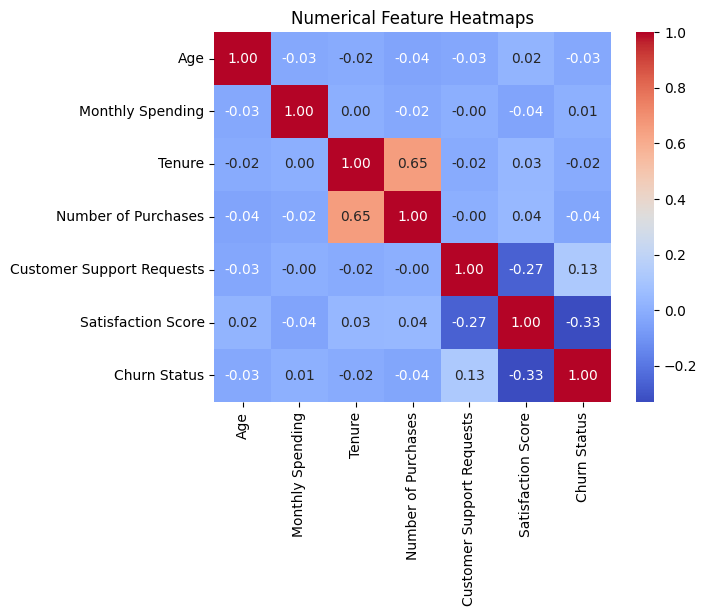

In [20]:
numeric_dataset = dataset.select_dtypes(include=['number'])

matrix = numeric_dataset.corr(method='pearson')
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numerical Feature Heatmaps')
plt.show()

In [21]:
log_model = LogisticRegression(max_iter = 300)
log_model.fit(X_train , y_train)
prediction = log_model.predict((X_test))
log_model_accuracy = accuracy_score(y_test , prediction)
print(f'Accuracy:{log_model_accuracy *100:.2f}%')
print(classification_report(y_test , prediction))


Accuracy:81.00%
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       242
           1       0.53      0.14      0.22        58

    accuracy                           0.81       300
   macro avg       0.68      0.55      0.56       300
weighted avg       0.77      0.81      0.76       300



In [36]:
xg_model = XGBClassifier()
xg_model.fit(X_train , y_train)
xg_model_prediction = xg_model.predict((X_test))
xg_model_acc = accuracy_score(y_test,xg_model_prediction)
print(f"Accuracy:{xg_model_acc*100:.2f}%")

Accuracy:76.00%


In [37]:
import pickle

with open('models/xg_boost.pkl','wb')as file:
    pickle.dump(xg_model , file)
print("Model saved successfully")

Model saved successfully


In [22]:
ann_model = Sequential([
    Dense(68, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
ann_model.fit(X_train , y_train , epochs=5)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6167 - loss: 2.2052 
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7000 - loss: 0.9165
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7250 - loss: 0.6190
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7575 - loss: 0.5573 
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7575 - loss: 0.5532


In [24]:
loss , accuracy = ann_model.evaluate(X_test , y_test)
print(f"accuracy: {accuracy:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8067 - loss: 0.5000  
accuracy: 0.81%


In [25]:
import pickle
with open('models/ann_model.pkl','wb')as file:
    pickle.dump(ann_model , file)
print('Model Saved Successfully')


Model Saved Successfully


- Saving my model

In [26]:
import pickle

with open('models/log_model.pkl','wb') as file:
    pickle.dump(log_model , file)

print("Model saved successfully")

Model saved successfully


- 1.1 — Save Feature Names

In [27]:
feature_names = X_train.columns.tolist()

with open('models/feature_names.pkl' ,'wb') as file:
    pickle.dump(feature_names , file)
print("Saved featured successfully")

Saved featured successfully


In [28]:
sample_prob = log_model.predict_proba(X_test)
print(sample_prob[:5])

[[0.81391038 0.18608962]
 [0.87414058 0.12585942]
 [0.89574853 0.10425147]
 [0.93068319 0.06931681]
 [0.78128655 0.21871345]]
